In [1]:
# import libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score

In [2]:
# load train and validation data

train_data = pd.read_csv("../data/train_data.csv", index_col=0)     # index_col=0 is the row where the index is saved; (I saved the csv file with index=True, so it saves the index to row nr 0)
validation_data = pd.read_csv("../data/validation_data.csv", index_col=0)

In [3]:
# split into X and y again:

X_train = train_data.drop('Irrigation_Need', axis=1)
y_train = train_data['Irrigation_Need']

X_valid = validation_data.drop('Irrigation_Need', axis=1)
y_valid = validation_data['Irrigation_Need']

In [7]:
X_train.shape

(441000, 35)

In [8]:
X_train.head()

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,...,Irrigation_Type_Rainfed,Irrigation_Type_Sprinkler,Water_Source_Rainwater,Water_Source_Reservoir,Water_Source_River,Region_East,Region_North,Region_South,Region_West,Mulching_Used
359466,0.464706,0.789437,0.884615,0.079412,0.864667,0.835834,0.006130,0.444286,0.572308,0.165986,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0
7717,0.261765,0.769258,0.184615,0.694118,0.434000,0.366195,0.857593,0.787143,0.047179,0.876190,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
626999,0.338235,0.284611,0.576923,0.861765,0.475000,0.867981,0.347376,0.540000,0.992308,0.846259,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0
558023,0.070588,0.332164,0.430769,0.041176,0.365333,0.071725,0.919894,0.990000,0.775385,0.180272,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1
518657,0.811765,0.442183,0.830769,0.297059,0.621000,0.915702,0.235561,0.704286,0.862051,0.257143,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0


In [9]:
y_train.head()

359466    1
7717      0
626999    1
558023    0
518657    0
Name: Irrigation_Need, dtype: int64

In [12]:
X_train.columns

Index(['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity',
       'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours',
       'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm',
       'Soil_Type_Loamy', 'Soil_Type_Sandy', 'Soil_Type_Silt',
       'Crop_Type_Maize', 'Crop_Type_Potato', 'Crop_Type_Rice',
       'Crop_Type_Sugarcane', 'Crop_Type_Wheat', 'Crop_Growth_Stage_Harvest',
       'Crop_Growth_Stage_Sowing', 'Crop_Growth_Stage_Vegetative',
       'Season_Rabi', 'Season_Zaid', 'Irrigation_Type_Drip',
       'Irrigation_Type_Rainfed', 'Irrigation_Type_Sprinkler',
       'Water_Source_Rainwater', 'Water_Source_Reservoir',
       'Water_Source_River', 'Region_East', 'Region_North', 'Region_South',
       'Region_West', 'Mulching_Used'],
      dtype='object')

In [ ]:
# colormap for heatmaps
from matplotlib.colors import LinearSegmentedColormap
custom_cmap = LinearSegmentedColormap.from_list(
    "gray_to_orange",
    ["#F0FFFF", "#E0E0E0", "#FFCC80", "#FF8C00", "#FE420F"]
)

In [4]:
# define baseline model

rf_low, rf_high = X_train["Rainfall_mm"].quantile([0.33, 0.66])
sm_low, sm_high = X_train["Soil_Moisture"].quantile([0.33, 0.66])
temp_low, temp_high = X_train["Temperature_C"].quantile([0.33, 0.66])
wind_low, wind_high = X_train['Wind_Speed_kmh'].quantile([0.33, 0.66])

def heuristic_model(row):

    Rainfall = row['Rainfall_mm']
    Soil_Moisture = row['Soil_Moisture']
    Temperature = row['Temperature_C']
    Wind_Speed = row['Wind_Speed_kmh']

    if (Soil_Moisture < sm_low) and (Temperature > temp_high) and (Rainfall < rf_low) and (Wind_Speed > wind_high):
        return 2  #high need for irrigation
    elif (sm_low <= Soil_Moisture <= sm_high) and (temp_low <= Temperature <= temp_high) and (rf_low <= Rainfall <= rf_high) and (wind_low <= Wind_Speed <= wind_high):
        return 1  # Medium need for irrig
    else:
        return 0  # Low need for irrig


# Apply baseline model to train data
y_pred_train_bl = X_train.apply(heuristic_model, axis=1)

# accuracy for train data
print("Heuristic model accuracy on train data:", accuracy_score(y_train, y_pred_train_bl))

# Apply baseline model to validation data
y_pred_valid_bl = X_valid.apply(heuristic_model, axis=1)

# accuracy for valid data
print("Heuristic model accuracy on validation data:", accuracy_score(y_valid, y_pred_valid_bl))


# y_pred_valid_prob_bl = np.zeros((len(y_pred_valid_bl), 3))
# for i, pred in enumerate(y_pred_valid_bl):
#     y_pred_valid_prob_bl[i, pred] = 1

# y_pred_from_prob = np.argmax(y_pred_valid_prob_bl, axis=1)    # turns one-hot matrix back into labels
# print('Accuracy of prob baseline model:', accuracy_score(y_valid, y_pred_from_prob))

Heuristic model accuracy on train data: 0.5874716553287982
Heuristic model accuracy on validation data: 0.5875714285714285


              precision    recall  f1-score   support

           0       0.59      0.98      0.74    110975
           1       0.21      0.01      0.01     71722
           2       0.45      0.22      0.30      6303

    accuracy                           0.59    189000
   macro avg       0.42      0.40      0.35    189000
weighted avg       0.44      0.59      0.45    189000

F1 macro score training set: 0.349465
F1 macro score validation set: 0.351049


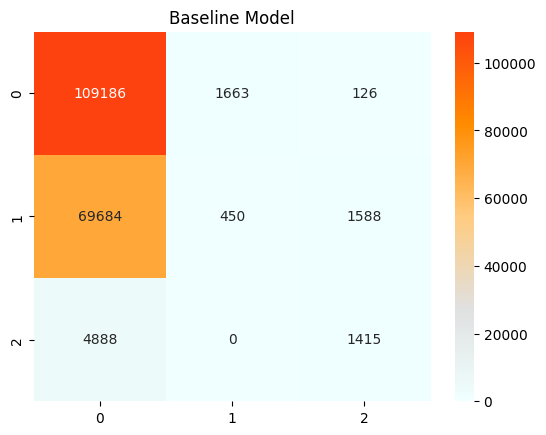

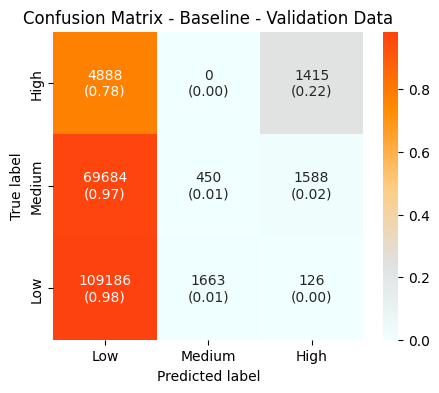

In [7]:
# evaluation

# classification report
print(classification_report(y_valid, y_pred_valid_bl))

# confusion matrix
cm = confusion_matrix(y_valid, y_pred_valid_bl)
sns.heatmap(cm, cmap=custom_cmap, annot=True, fmt='d')
plt.title('Baseline Model')

##################################################################
# nicer confusion matrix for presentation

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

annot_bl = np.empty_like(cm).astype(str)

for i in range(cm.shape[0]):
   for j in range(cm.shape[1]):
       annot_bl[i, j] = f"{cm[i, j]}\n({cm_norm[i, j]:.2f})"


# plot heatmap
fig, ax = plt.subplots(1, 1, figsize=(5, 4))

sns.heatmap(cm_norm, cmap=custom_cmap, annot=annot_bl, fmt="", ax=ax, yticklabels=["Low", "Medium", "High"], xticklabels=["Low", "Medium", "High"])
ax.set_title("Confusion Matrix - Baseline - Validation Data")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.invert_yaxis()

# print F1 macro score
print('F1 macro score training set:', f1_score(y_train, y_pred_train_bl, average='macro').round(6))
print('F1 macro score validation set:', f1_score(y_valid, y_pred_valid_bl, average='macro').round(6))
